
# HW2: Exploratory Data Analysis - International Coastal Cleanup
**Background:** This dataset contains information on trash collected during coastal cleanup events, sourced from the Norfolk OpenData Portal. The goal of this EDA is to investigate the structure of the data, understand missing values, and uncover relationships between cleanup efforts (volunteers, hours) and the amount/types of trash collected.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Load the dataset
df = pd.read_csv('../data/International_Coastal_Cleanup.csv')

### 1. Data Size and Types
Let's look at how many rows and columns we have, and what data types make up the dataset.

In [3]:
# Size of the dataset (rows, columns)
print("Dataset Shape:", df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (77, 53)

Data Types:
Area                                             str
Date                                             str
Cigarette Butts                                  str
Food Wrappers (candy, chips, etc.)               str
Take Out/Away Containers (Plastic)             int64
Take Out/Away Containers (Foam)                int64
Bottle Caps (Plastic)                          int64
Bottle Caps (Metal)                              str
Lids (Plastic)                                 int64
Straws, Stirrers                               int64
Forks, Knives, Spoons                          int64
Beverage Bottles (Plastic)                     int64
Beverage Bottles (Glass)                         str
Beverage Cans                                  int64
Grocery Bags (Plastic)                         int64
Other Plastic Bags                             int64
Paper Bags                                     int64
Cups, Plates (Paper)                           int64
Cups, Pla

### 2. Missing Data
Next, we check if any columns contain missing data points (null values).

In [4]:
# Check for missing values in each column
missing_data = df.isnull().sum()
print("Missing Data per Column:\n", missing_data[missing_data > 0])

Missing Data per Column:
 Series([], dtype: int64)


### 3. Descriptive Statistics & Distributions
We will look at the summary statistics (mean, median, standard deviation) for our numerical columns, focusing on cleanup effort metrics. We will also visualize the distribution of 'Number of Volunteers'.

,Take Out/Away Containers (Plastic),Take Out/Away Containers (Foam),Bottle Caps (Plastic),Lids (Plastic),"Straws, Stirrers","Forks, Knives, Spoons",Beverage Bottles (Plastic),Beverage Cans,Grocery Bags (Plastic),Other Plastic Bags,...,Toys,Other Trash (Clean Swell),Condoms,Diapers,Syringes,Tampons/Tampon Applicators,Foam Pieces,Number of Volunteers,Volunteer Hours,Number of Miles
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,...,77.000000,77.000000,77.000000,77.000000,77.00000,77.000000,77.000000,77.000000,77.00000,77.000000
mean,18.363636,13.714286,98.337662,23.350649,50.558442,13.909091,68.922078,44.350649,38.961039,36.233766,...,0.168831,18.961039,1.909091,1.259740,0.61039,0.922078,64.441558,18.896104,37.37013,1.530909
std,21.944253,18.943724,148.793093,26.738877,62.141920,20.238825,92.227089,55.825331,59.709922,77.109269,...,0.864544,67.232989,4.205829,3.743073,1.94771,2.113654,128.515767,27.249135,57.04352,1.486711
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,3.000000,1.000000,16.000000,6.000000,11.000000,1.000000,15.000000,6.000000,5.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,5.000000,9.00000,1.000000
50%,8.000000,6.000000,43.000000,13.000000,24.000000,7.000000,34.000000,26.000000,17.000000,10.000000,...,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,14.000000,11.000000,22.00000,1.000000
75%,31.000000,19.000000,107.000000,33.000000,72.000000,20.000000,70.000000,67.000000,44.000000,34.000000,...,0.000000,1.000000,2.000000,1.000000,1.00000,1.000000,58.000000,22.000000,38.00000,2.000000
max,90.000000,106.000000,780.000000,109.000000,368.000000,136.000000,395.000000,276.000000,326.000000,542.000000,...,7.000000,441.000000,33.000000,24.000000,15.00000,14.000000,750.000000,178.000000,396.00000,10.000000


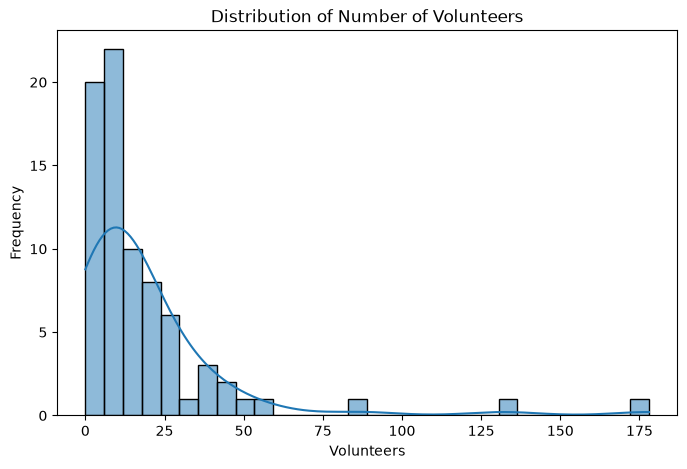

In [5]:
# Descriptive statistics
display(df.describe())

# Histogram of Volunteers
plt.figure(figsize=(8, 5))
sns.histplot(df['Number of Volunteers'].dropna(), bins=30, kde=True)
plt.title('Distribution of Number of Volunteers')
plt.xlabel('Volunteers')
plt.ylabel('Frequency')
plt.show()

### 4. Outliers
To identify outliers, we can use a boxplot. Let's check for outliers in 'Volunteer Hours' and 'Number of Miles'.

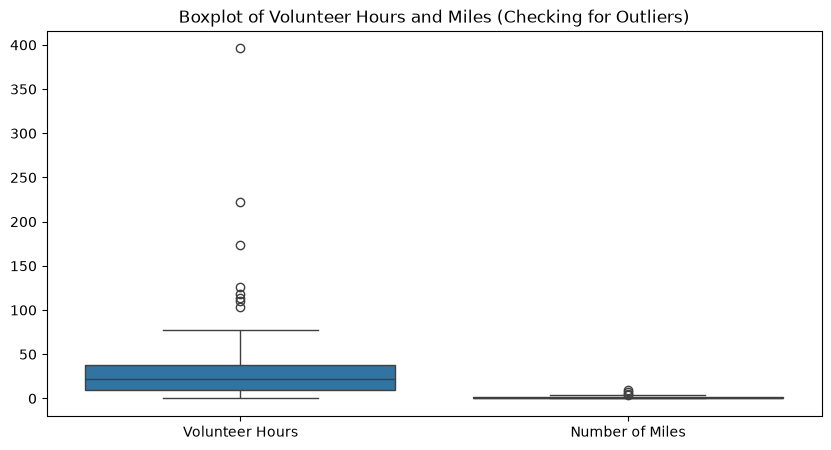

In [6]:
# Boxplot for Outliers
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['Volunteer Hours', 'Number of Miles']])
plt.title('Boxplot of Volunteer Hours and Miles (Checking for Outliers)')
plt.show()

### 5. Relationships and Correlations
How do variables relate to each other? Let's check the correlation matrix and plot a scatterplot between Volunteers and Volunteer Hours.

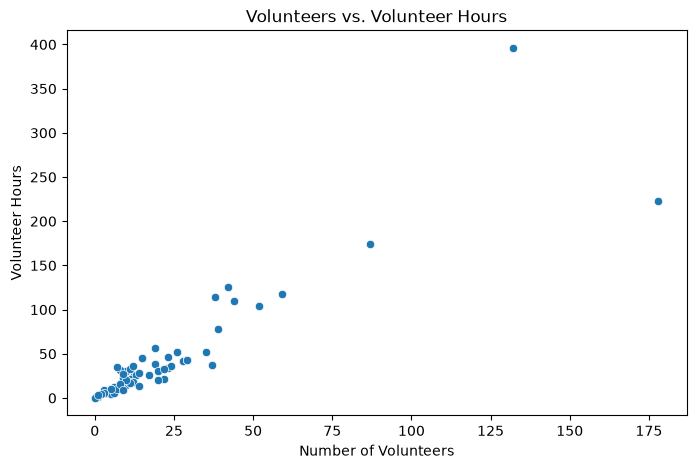

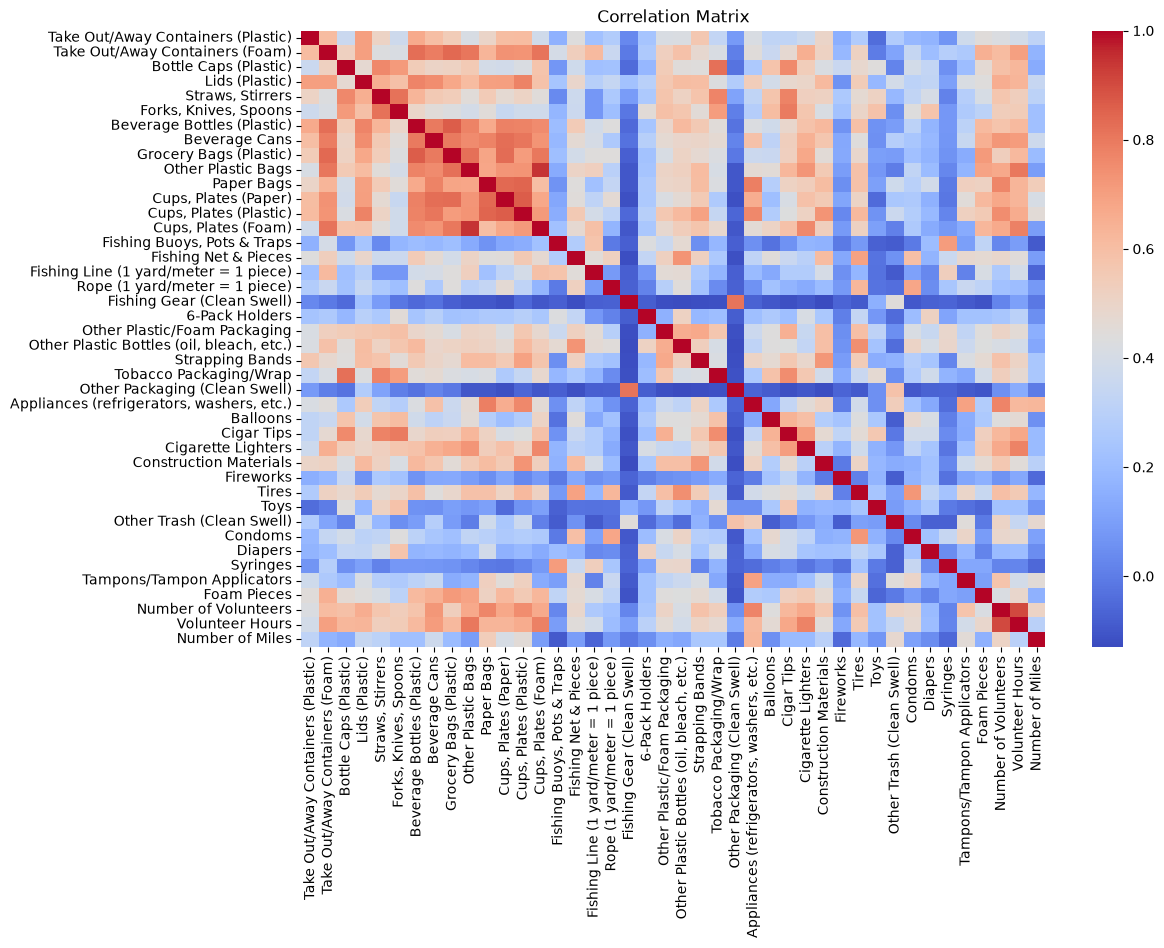

In [7]:
# Scatterplot
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Number of Volunteers', y='Volunteer Hours', data=df)
plt.title('Volunteers vs. Volunteer Hours')
plt.show()

# Correlation Matrix (Numeric columns only)
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### 6. Initial Conclusions
Based on this EDA, we can see that:
1. The dataset contains a wide variety of trash types with varying levels of missing data.
2. There is a strong positive correlation between the Number of Volunteers and Volunteer Hours.
3. The data contains heavy outliers, likely representing a few massive community cleanup events compared to mostly smaller, localized efforts.